# F1 Race Finish Position Predictor

## Problem Statement
Predict the finishing position of an F1 driver in a race using
historical data from the Ergast F1 dataset (2010–2023).

## Features Used
- Grid (qualifying) position
- Constructor (team)
- Driver
- Average points scored in last 3 races
- Circuit

## Model
XGBoost Regressor — chosen over Random Forest for better
accuracy on structured tabular data.

## Result
MAE: ~2.87 positions on unseen 2010–2023 race data
using a time-based train-test split.

In [1]:
import pandas as pd

results      = pd.read_csv('results.csv')
races        = pd.read_csv('races.csv')
drivers      = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
qualifying   = pd.read_csv('qualifying.csv')

print("Results shape:", results.shape)
print("Races shape:", races.shape)
print("Drivers shape:", drivers.shape)
print("Constructors shape:", constructors.shape)
print("Qualifying shape:", qualifying.shape)

Results shape: (7600, 9)
Races shape: (1149, 7)
Drivers shape: (616, 5)
Constructors shape: (168, 4)
Qualifying shape: (3017, 7)


In [2]:
results.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status
0,1950_1,farina,alfa,1,1,1,9.0,70,Finished
1,1950_1,fagioli,alfa,2,2,2,6.0,70,Finished
2,1950_1,reg_parnell,alfa,4,3,3,4.0,70,Finished
3,1950_1,cabantous,lago,6,4,4,3.0,68,+2 Laps
4,1950_1,rosier,lago,9,5,5,2.0,68,+2 Laps


In [3]:
df = results.merge(races, on='race_id')
df.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,season,round,race_name,date,time,circuit_id
0,1950_1,farina,alfa,1,1,1,9.0,70,Finished,1950,1,British Grand Prix,1950-05-13,NaN,silverstone
1,1950_1,fagioli,alfa,2,2,2,6.0,70,Finished,1950,1,British Grand Prix,1950-05-13,NaN,silverstone
2,1950_1,reg_parnell,alfa,4,3,3,4.0,70,Finished,1950,1,British Grand Prix,1950-05-13,NaN,silverstone
3,1950_1,cabantous,lago,6,4,4,3.0,68,+2 Laps,1950,1,British Grand Prix,1950-05-13,NaN,silverstone
4,1950_1,rosier,lago,9,5,5,2.0,68,+2 Laps,1950,1,British Grand Prix,1950-05-13,NaN,silverstone


In [4]:
df = df[df['season'] >= 2010]
print("Shape after filtering:", df.shape)

Shape after filtering: (1600, 15)


In [5]:
df = df[['race_id', 'driver_id', 'constructor_id', 'grid', 'position_order', 'points', 'season','circuit_id']]
df.head()

,race_id,driver_id,constructor_id,grid,position_order,points,season,circuit_id
6000,2010_1,alonso,ferrari,3,1,25.0,2010,bahrain
6001,2010_1,massa,ferrari,2,2,18.0,2010,bahrain
6002,2010_1,hamilton,mclaren,4,3,15.0,2010,bahrain
6003,2010_1,vettel,red_bull,1,4,12.0,2010,bahrain
6004,2010_1,rosberg,mercedes,5,5,10.0,2010,bahrain


In [6]:
df[['grid', 'position_order']].corr()

,grid,position_order
grid,1.000000,0.631341
position_order,0.631341,1.000000


In [7]:
pole_wins = df[(df['grid'] == 1) & (df['position_order'] == 1)]
print("Pole to win count:", len(pole_wins))

Pole to win count: 41


In [8]:
df.groupby('constructor_id')['position_order'].mean().sort_values().head(10)

constructor_id
mercedes         5.529032
red_bull         6.308176
ferrari          6.474684
mclaren          9.346154
racing_point    10.250000
lotus_f1        10.342105
aston_martin    10.860000
force_india     11.292683
renault         11.734375
alphatauri      12.650000
Name: position_order, dtype: float64

In [9]:
df = df.sort_values(['driver_id', 'season'])

df['points_last_3'] = df.groupby('driver_id')['points'].rolling(3).mean().reset_index(0, drop=True)

df.head(10)

,race_id,driver_id,constructor_id,grid,position_order,points,season,circuit_id,points_last_3
6913,2019_1,albon,toro_rosso,13,14,0.0,2019,albert_park,NaN
6928,2019_2,albon,toro_rosso,12,9,2.0,2019,bahrain,NaN
6949,2019_3,albon,toro_rosso,0,10,1.0,2019,shanghai,1.000000
6970,2019_4,albon,toro_rosso,11,11,0.0,2019,baku,1.000000
6990,2019_5,albon,toro_rosso,11,11,0.0,2019,catalunya,0.333333
7012,2020_1,albon,red_bull,4,13,0.0,2020,red_bull_ring,0.000000
7023,2020_2,albon,red_bull,6,4,12.0,2020,red_bull_ring,4.000000
7044,2020_3,albon,red_bull,13,5,10.0,2020,hungaroring,7.333333
7067,2020_4,albon,red_bull,12,8,4.0,2020,silverstone,8.666667
7084,2020_5,albon,red_bull,9,5,10.0,2020,silverstone,8.000000


In [10]:
# Fill missing values with zero  the first 2 races for each driver have no "last 3 average"
df['points_last_3'] = df['points_last_3'].fillna(0)

# Encode categorical data
from sklearn.preprocessing import LabelEncoder

le_driver = LabelEncoder()
le_constructor = LabelEncoder()

df['driver_encoded'] = le_driver.fit_transform(df['driver_id'])
df['constructor_encoded'] = le_constructor.fit_transform(df['constructor_id'])

df.head()

,race_id,driver_id,constructor_id,grid,position_order,points,season,circuit_id,points_last_3,driver_encoded,constructor_encoded
6913,2019_1,albon,toro_rosso,13,14,0.0,2019,albert_park,0.000000,0,20
6928,2019_2,albon,toro_rosso,12,9,2.0,2019,bahrain,0.000000,0,20
6949,2019_3,albon,toro_rosso,0,10,1.0,2019,shanghai,1.000000,0,20
6970,2019_4,albon,toro_rosso,11,11,0.0,2019,baku,1.000000,0,20
6990,2019_5,albon,toro_rosso,11,11,0.0,2019,catalunya,0.333333,0,20


In [11]:
from sklearn.preprocessing import LabelEncoder
import joblib

le_circuit = LabelEncoder()
df['circuit_encoded'] = le_circuit.fit_transform(df['circuit_id'])

print("Circuits encoded. Total unique circuits:", len(le_circuit.classes_))
print("Example — monaco =", le_circuit.transform(['monaco'])[0])

joblib.dump(le_circuit, 'le_circuit.pkl')
print("le_circuit.pkl saved!")

Circuits encoded. Total unique circuits: 17
Example — monaco = 9
le_circuit.pkl saved!


In [12]:
X = df[['grid', 'points_last_3', 'driver_encoded', 'constructor_encoded','circuit_encoded']]
y = df['position_order']

In [13]:
train_df = df[df['season'] <= 2021]
test_df  = df[df['season'] >= 2022]

features = ['grid', 'points_last_3',
            'driver_encoded', 'constructor_encoded',
            'circuit_encoded']

X_train = train_df[features]
y_train = train_df['position_order']

X_test  = test_df[features]
y_test  = test_df['position_order']

print("Training races (2010-2021):", X_train.shape)
print("Testing races  (2022+):    ", X_test.shape)

Training races (2010-2021): (1200, 5)
Testing races  (2022+):     (400, 5)


In [14]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest MAE:", round(mean_absolute_error(y_test, rf_pred), 2))

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
xgb_pred = model.predict(X_test)
print("XGBoost MAE:      ", round(mean_absolute_error(y_test, xgb_pred), 2))

Random Forest MAE: 3.02
XGBoost MAE:       2.87


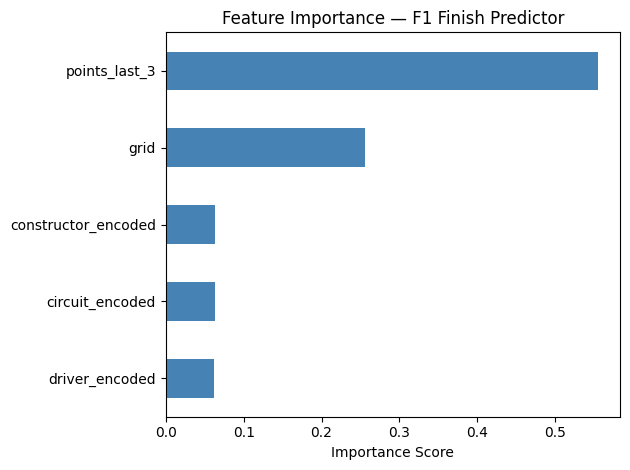

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

features = ['grid', 'points_last_3',
            'driver_encoded', 'constructor_encoded',
            'circuit_encoded']

importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — F1 Finish Predictor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [16]:
import joblib
joblib.dump(model,          'f1_model.pkl')
joblib.dump(le_driver,      'le_driver.pkl')
joblib.dump(le_constructor, 'le_constructor.pkl')
joblib.dump(le_circuit,     'le_circuit.pkl')


print("Model saved!,Hurry")

Model saved!,Hurry
